In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np
import pickle

# Manual dataset creation (No need to upload Ecommerce.csv!)
data = {
    'experience': [0, 0, 5, 2, 7, 3, 10, 11], 
    'test_score': [8.0, 8.0, 6.0, 10.0, 9.0, 7.0, 8.0, 7.0], 
    'interview_score': [9, 6, 7, 10, 6, 10, 7, 8],
    'salary': [50000, 45000, 70000, 60000, 75000, 62000, 72000, 80000]
}

df = pd.DataFrame(data)
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   experience  test_score  interview_score  salary
0           0         8.0                9   50000
1           0         8.0                6   45000
2           5         6.0                7   70000
3           2        10.0               10   60000
4           7         9.0                6   75000


In [12]:
# Features (experience, test_score, interview_score)
X = df[['experience', 'test_score', 'interview_score']]

# Target variable (salary)
y = df['salary']

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [13]:
lm = LinearRegression()
lm.fit(X_train, y_train)

print("Model Training Complete.")
print("Coefficients:", lm.coef_)

Model Training Complete.
Coefficients: [2847.12950601 1656.60881175 1282.6435247 ]


In [14]:
predictions = lm.predict(X_test)

print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2 Score:', metrics.r2_score(y_test, predictions))

RMSE: 7415.573232815799
R2 Score: 0.4500927362874584


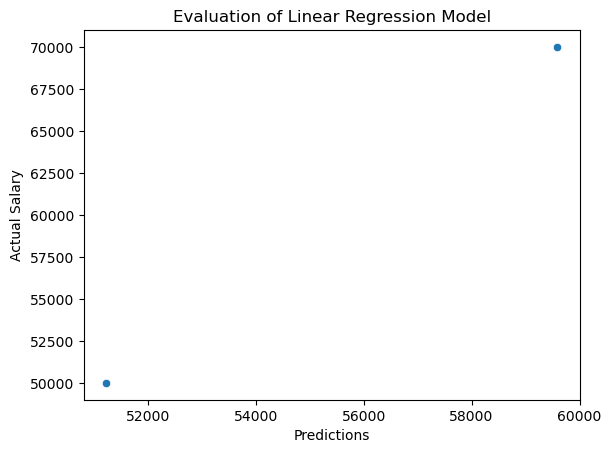

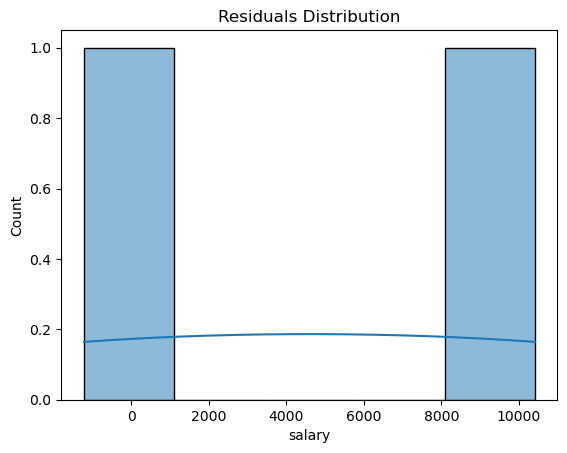

In [15]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions")
plt.ylabel("Actual Salary")
plt.title("Evaluation of Linear Regression Model")
plt.show()

# Residual histogram check
sns.histplot((y_test - predictions), bins=5, kde=True)
plt.title("Residuals Distribution")
plt.show()

In [16]:
with open('model.pkl', 'wb') as file:
    pickle.dump(lm, file)
print("Model saved as model.pkl successfully!")

Model saved as model.pkl successfully!
